# 15 — Walk-Forward ML Challenger vs Baseline Robot vs BIST100

Bu notebook ayrı ve dürüst bir ML karşılaştırması üretir.

**Neden başlangıç 2025?**

`Big_Winner_Label_2R`, Logistic Regression ve Q40 filtresi 2018–2024
araştırmasıyla seçildi. Bunları 2018'e geri uygulayıp tam dönem grafik
oluşturmak seçim yanlılığı yaratır. Bu nedenle karşılaştırma 2025'te başlar.

**Walk-forward akışı**

- Her ayın başında model yeniden eğitilir.
- Yalnızca o tarihten önce sinyali oluşmuş ve 5 günlük embargo öncesinde
  kapanmış işlemler eğitime girer.
- Model tipi ve Q40 eşiği değiştirilmez.
- Ay içindeki günlük Robot AL satırları yeni modelle skorlanır.
- Baseline Robot, ML Challenger ve BIST100 aynı tarihlerde karşılaştırılır.

2025+ sonuçları daha önce incelendiği için kusursuz bir holdout değildir;
ancak tahmin üretiminde gelecekteki işlem sonucu kullanılmaz.


In [5]:
from pathlib import Path
import json
import sys

import pandas as pd

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.features import add_indicators
from src.signals import (
    build_market_regime,
    add_robot_scores,
)
from src.presets import (
    FINAL_STRATEGY_CONFIG,
    FINAL_PORTFOLIO_CONFIG,
)
from src.ml_dataset import (
    BASE_FEATURE_COLUMNS,
    add_meta_features,
)
from src.ml_targets import add_alternative_targets
from src.dual_paper import (
    load_challenger_deployment,
    deployment_summary,
)
from src.ml_walkforward import (
    WalkForwardConfig,
    generate_walk_forward_probabilities,
    evaluate_walk_forward_comparison,
    save_walk_forward_artifacts,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Veri ve kilitli ML kararını yükle


In [6]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

events = pd.read_parquet(
    PROJECT_ROOT
    / "results"
    / "ml"
    / "robot_meta_label_training.parquet"
)

for column in [
    "Signal_Date",
    "Entry_Date",
    "Exit_Date",
]:
    events[column] = pd.to_datetime(
        events[column]
    )

events = add_alternative_targets(events)

deployment, _ = load_challenger_deployment(
    PROJECT_ROOT
)

display(deployment_summary(deployment))

if deployment.target != "Big_Winner_Label_2R":
    raise RuntimeError(
        "Beklenen hedef Big_Winner_Label_2R değil."
    )

if deployment.probability_threshold is None:
    raise RuntimeError(
        "Kilitli olasılık eşiği bulunamadı."
    )


,Target,Model,Filter,Probability_Threshold,Keep_Top_Fraction,Model_Path
0,Big_Winner_Label_2R,LogisticRegression,Quantile_Q40,0.511306,None,c:\Users\okand\Desktop\Projects\Algorithmic Tr...


## 2. Robot ve ML özelliklerini hazırla


In [7]:
stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(
    market_features
)

scored_prices = add_robot_scores(
    stock_features=stock_features,
    market_regime=market_regime,
    config=FINAL_STRATEGY_CONFIG,
    include_reasons=False,
)

featured_prices = add_meta_features(
    scored_prices=scored_prices,
    market_features=market_features,
)

WALK_FORWARD_START = "2025-01-01"
WALK_FORWARD_END = min(
    featured_prices["Date"].max(),
    market_prices["Date"].max(),
).strftime("%Y-%m-%d")

print(
    "Walk-forward dönemi:",
    WALK_FORWARD_START,
    "→",
    WALK_FORWARD_END,
)


Walk-forward dönemi: 2025-01-01 → 2026-07-23


## 3. Aylık walk-forward olasılıkları üret


In [8]:
walk_forward_config = WalkForwardConfig(
    start=WALK_FORWARD_START,
    end=WALK_FORWARD_END,
    retrain_frequency="MS",
    embargo_days=5,
    minimum_training_events=500,
    random_state=42,
)

probability_prices, training_log = (
    generate_walk_forward_probabilities(
        featured_prices=featured_prices,
        events=events,
        model_name=deployment.model_name,
        target_column=deployment.target,
        feature_columns=BASE_FEATURE_COLUMNS,
        config=walk_forward_config,
    )
)

display(training_log)

print(
    "Minimum skor kapsaması:",
    training_log["Score_Coverage_%"].min(),
)


,Block,Block_Start,Block_End,Purge_Boundary,Training_Event_Count,Training_Signal_Start,Training_Signal_End,Training_Exit_End,Training_Positive_Rate_%,Robot_AL_Rows,Scored_AL_Rows,Score_Coverage_%,Rows_With_Imputation,Missing_Feature_Cells,Rows_With_Imputation_%,Probability_Mean,Probability_Std
0,1,2025-01-01,2025-01-31,2024-12-27,2915,2019-01-18,2024-12-17,2024-12-24,21.029160,286,286,100.0,286,336,100.000000,0.356209,0.074536
1,2,2025-02-01,2025-02-28,2025-01-27,2948,2019-01-18,2025-01-13,2025-01-24,20.963365,138,138,100.0,127,137,92.028986,0.349655,0.066988
2,3,2025-03-01,2025-03-31,2025-02-24,2997,2019-01-18,2025-02-20,2025-02-21,20.854188,342,342,100.0,8,21,2.339181,0.514760,0.077552
3,4,2025-04-01,2025-04-30,2025-03-27,3076,2019-01-18,2025-03-20,2025-03-24,20.546164,57,57,100.0,0,0,0.000000,0.366277,0.095455
4,5,2025-05-01,2025-05-31,2025-04-26,3087,2019-01-18,2025-04-15,2025-04-22,20.505345,91,91,100.0,1,2,1.098901,0.380600,0.096193
5,6,2025-06-01,2025-06-30,2025-05-27,3115,2019-01-18,2025-05-16,2025-05-21,20.449438,92,92,100.0,0,0,0.000000,0.486032,0.123159
6,7,2025-07-01,2025-07-31,2025-06-26,3146,2019-01-18,2025-06-12,2025-06-23,20.279720,392,392,100.0,0,0,0.000000,0.554255,0.115537
7,8,2025-08-01,2025-08-31,2025-07-27,3174,2019-01-18,2025-07-10,2025-07-25,20.226843,461,461,100.0,0,0,0.000000,0.401167,0.096211
8,9,2025-09-01,2025-09-30,2025-08-27,3229,2019-01-18,2025-08-22,2025-08-26,20.099102,303,303,100.0,0,0,0.000000,0.385860,0.114476
9,10,2025-10-01,2025-10-31,2025-09-26,3312,2019-01-18,2025-09-17,2025-09-25,20.078502,253,253,100.0,0,0,0.000000,0.499486,0.132645


Minimum skor kapsaması: 100.0


## 4. Üç portföyü aynı dönemde karşılaştır


In [9]:
(
    comparison_metrics,
    equity_comparison,
    yearly_table,
    active_table,
    walk_forward_outputs,
) = evaluate_walk_forward_comparison(
    probability_prices=probability_prices,
    market_prices=market_prices,
    probability_threshold=(
        deployment.probability_threshold
    ),
    strategy_config=FINAL_STRATEGY_CONFIG,
    portfolio_config=FINAL_PORTFOLIO_CONFIG,
    start=WALK_FORWARD_START,
    end=WALK_FORWARD_END,
)

display(comparison_metrics)
display(active_table)
display(yearly_table)


,Portfolio,Start_Value,End_Value,Total_Return_%,CAGR_%,Max_Drawdown_%,Profit_Factor,Win_Rate_%,Expectancy_%,Sharpe,Sortino,Calmar,Trade_Count,Exposure_%,Signal_Pass_Rate_%,Outlier_Count,Average_Open_Positions,Max_Open_Positions,Average_Invested_%
0,Baseline_Robot,500000.0,9.944576e+05,98.891522,55.726527,-10.930242,2.038285,30.177515,4.704486,2.244071,3.425195,5.098380,169,99.484536,100.000000,NaN,NaN,NaN,NaN
1,ML_Challenger,500000.0,1.018721e+06,103.744143,58.163559,-12.334559,2.705351,33.333333,6.606668,2.541827,3.245643,4.715495,117,93.041237,33.042995,NaN,NaN,NaN,NaN
2,BIST100_Gross,500000.0,7.066234e+05,41.324676,24.958964,-17.061152,NaN,NaN,NaN,1.037176,1.467252,1.462912,0,100.000000,NaN,0.0,1.0,1.0,100.0


,Alpha_Annual_%,Beta,Correlation,Tracking_Error_%,Information_Ratio,Upside_Capture_%,Downside_Capture_%,Active_Total_Return_pp,Strategy_Annual_Volatility_%,Benchmark_Annual_Volatility_%,Portfolio
0,36.592249,0.410345,0.484289,23.429246,0.916176,55.382880,29.593852,57.566845,20.957810,24.73437,Baseline_Robot
1,37.119720,0.435976,0.568871,20.920642,1.082677,54.048818,27.063064,62.419466,18.956119,24.73437,ML_Challenger


Portfolio,Year,BIST100_Gross,Baseline_Robot,ML_Challenger
0,2025,13.053114,36.068742,33.400257
1,2026,25.007328,46.169884,52.731447


## 5. Portföy değer eğrisi


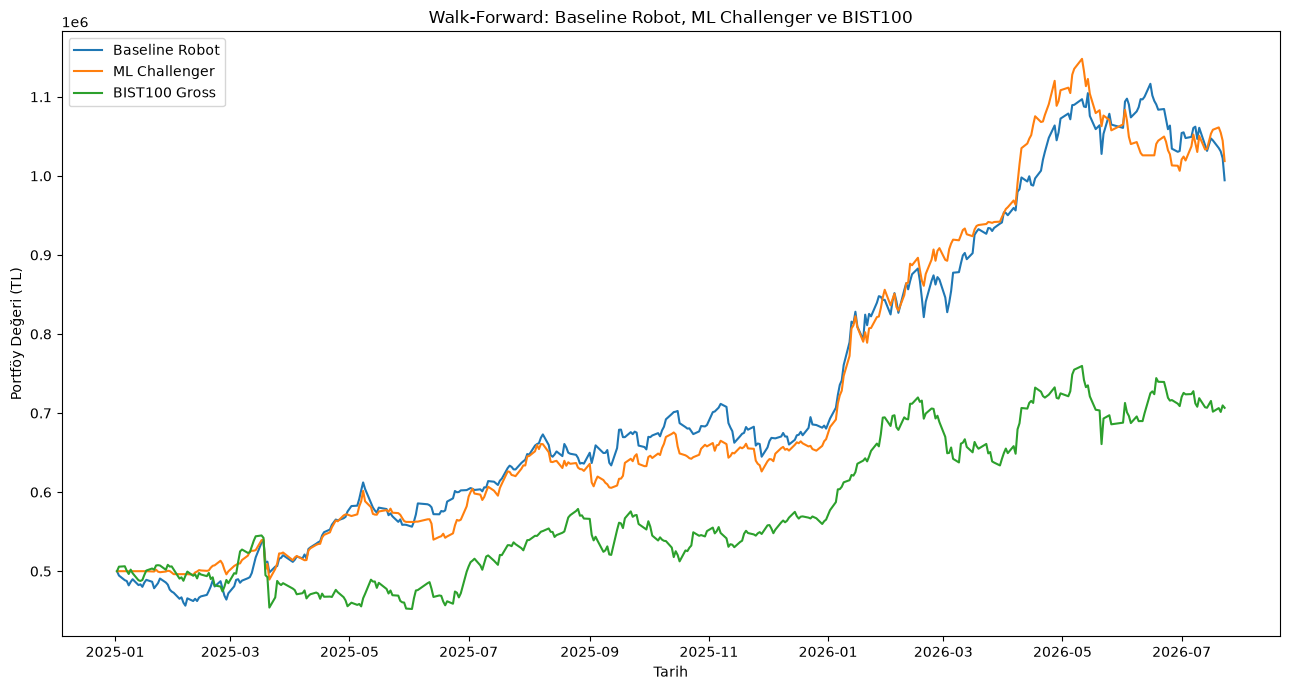

In [10]:
import matplotlib.pyplot as plt

chart = equity_comparison.set_index("Date")

plt.figure(figsize=(13, 7))
plt.plot(
    chart.index,
    chart["Baseline_Robot"],
    label="Baseline Robot",
)
plt.plot(
    chart.index,
    chart["ML_Challenger"],
    label="ML Challenger",
)
plt.plot(
    chart.index,
    chart["BIST100_Gross"],
    label="BIST100 Gross",
)
plt.title(
    "Walk-Forward: Baseline Robot, ML Challenger ve BIST100"
)
plt.xlabel("Tarih")
plt.ylabel("Portföy Değeri (TL)")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Sonuçları dashboard için kaydet


In [11]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml"
    / "walk_forward"
)

metadata = {
    "method": "Monthly expanding walk-forward",
    "start": WALK_FORWARD_START,
    "end": WALK_FORWARD_END,
    "retrain_frequency": (
        walk_forward_config.retrain_frequency
    ),
    "embargo_days": (
        walk_forward_config.embargo_days
    ),
    "target": deployment.target,
    "model": deployment.model_name,
    "filter": deployment.filter_name,
    "probability_threshold": (
        deployment.probability_threshold
    ),
    "feature_count": len(
        BASE_FEATURE_COLUMNS
    ),
    "selection_window": "2018-2024",
    "evaluation_window": "2025+",
    "warning": (
        "2025+ was previously inspected; this is a "
        "leakage-controlled audit, not a pristine holdout."
    ),
}

artifact_paths = save_walk_forward_artifacts(
    output_directory=OUTPUT_DIR,
    comparison_metrics=comparison_metrics,
    equity_comparison=equity_comparison,
    yearly_table=yearly_table,
    active_table=active_table,
    training_log=training_log,
    probability_prices=probability_prices,
    metadata=metadata,
)

for name, path in artifact_paths.items():
    print(name, "→", path)


metrics → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_comparison_metrics.csv
equity → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_equity.parquet
yearly → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_yearly.csv
active → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_active_metrics.csv
training_log → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_training_log.csv
probabilities → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_probabilities.parquet
metadata → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_metadata.json


In [13]:
import numpy as np
audit_features = featured_prices.loc[
    featured_prices["Date"].between(
        "2025-01-01",
        "2025-02-28",
    )
    & featured_prices["Signal"].eq("AL"),
    ["Date", "Ticker", *BASE_FEATURE_COLUMNS],
].copy()

records = []

for month, group in audit_features.groupby(
    audit_features["Date"].dt.to_period("M")
):
    missing_counts = (
        group[BASE_FEATURE_COLUMNS]
        .replace([np.inf, -np.inf], np.nan)
        .isna()
        .sum()
    )

    for feature, count in missing_counts[
        missing_counts.gt(0)
    ].items():
        records.append(
            {
                "Month": str(month),
                "Feature": feature,
                "Missing_Count": int(count),
                "Event_Count": len(group),
                "Missing_Rate_%": (
                    count / len(group) * 100
                ),
            }
        )

missing_feature_audit = (
    pd.DataFrame(records)
    .sort_values(
        ["Month", "Missing_Count"],
        ascending=[True, False],
    )
)

display(missing_feature_audit)

,Month,Feature,Missing_Count,Event_Count,Missing_Rate_%
7,2025-01,MARKET_RET_63,286,286,100.000000
1,2025-01,RET_20,15,286,5.244755
2,2025-01,VOLATILITY_20,15,286,5.244755
0,2025-01,RET_5,4,286,1.398601
3,2025-01,EMA20_SLOPE_5,4,286,1.398601
4,2025-01,EMA50_SLOPE_5,4,286,1.398601
5,2025-01,ADX_CHANGE_5,4,286,1.398601
6,2025-01,RSI_CHANGE_5,4,286,1.398601
10,2025-02,MARKET_RET_63,127,138,92.028986
8,2025-02,RET_20,5,138,3.623188


In [14]:
market_diagnostics = pd.DataFrame(
    [
        {
            "Dataset": "market_prices",
            "Start": market_prices["Date"].min(),
            "End": market_prices["Date"].max(),
            "Rows": len(market_prices),
        },
        {
            "Dataset": "market_features",
            "Start": market_features["Date"].min(),
            "End": market_features["Date"].max(),
            "Rows": len(market_features),
        },
        {
            "Dataset": "featured_prices MARKET_RET_63",
            "Start": featured_prices.loc[
                featured_prices["MARKET_RET_63"].notna(),
                "Date",
            ].min(),
            "End": featured_prices.loc[
                featured_prices["MARKET_RET_63"].notna(),
                "Date",
            ].max(),
            "Rows": featured_prices[
                "MARKET_RET_63"
            ].notna().sum(),
        },
    ]
)

display(market_diagnostics)

,Dataset,Start,End,Rows
0,market_prices,2024-02-08,2026-07-23,609
1,market_features,2024-11-28,2026-07-23,410
2,featured_prices MARKET_RET_63,2025-02-27,2026-07-23,33650
